# Performance Analytics

This notebook performs financial performance analysis on the mutual fund dataset. The analysis includes daily return calculation, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard generation, and Benchmark Comparison.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

In [2]:
DATA_DIR = Path("../data/processed")
ANALYTICS_DIR = Path("../data/analytics")

fund_master = pd.read_csv(DATA_DIR / "clean_fund_master.csv")

nav_history = pd.read_csv(DATA_DIR / "clean_nav_history.csv")

benchmark_indices = pd.read_csv(DATA_DIR / "clean_benchmark_indices.csv")

scheme_performance = pd.read_csv(DATA_DIR / "clean_scheme_performance.csv")

In [3]:
print("Fund Master:", fund_master.shape)

print("NAV History:", nav_history.shape)

print("Benchmark Indices:", benchmark_indices.shape)

print("Scheme Performance:", scheme_performance.shape)

Fund Master: (40, 15)
NAV History: (64320, 3)
Benchmark Indices: (8050, 3)
Scheme Performance: (40, 21)


### Task 1 — Daily Returns
Objective:
Calculate the daily percentage return for every mutual fund scheme using daily NAV values.

In [4]:
daily_returns_df = nav_history.copy()

daily_returns_df = daily_returns_df[
    [
        "date",
        "amfi_code",
        "nav",
    ]
].copy()

daily_returns_df["date"] = pd.to_datetime(
    daily_returns_df["date"]
)

daily_returns_df = (
    daily_returns_df
    .sort_values(
        ["amfi_code", "date"]
    )
    .reset_index(drop=True)
)

print("Shape:", daily_returns_df.shape)
print("Unique Schemes:", daily_returns_df["amfi_code"].nunique())

daily_returns_df.head()

Shape: (64320, 3)
Unique Schemes: 40


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


The daily percentage return is calculated separately for each mutual fund scheme using the previous trading day's NAV.

In [5]:
daily_returns_df["daily_return"] = (
    daily_returns_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

daily_returns_df.head(10)

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000
6,2022-01-09,100016,515.1639,0.000000
7,2022-01-10,100016,510.7136,-0.008639
8,2022-01-11,100016,513.5542,0.005562
9,2022-01-12,100016,512.3195,-0.002404


In [6]:
print("Missing daily returns:")
print(daily_returns_df["daily_return"].isna().sum())

print("\nDaily Return Statistics:")
print(daily_returns_df["daily_return"].describe())

daily_returns_df.head(10)

Missing daily returns:
40

Daily Return Statistics:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000
6,2022-01-09,100016,515.1639,0.000000
7,2022-01-10,100016,510.7136,-0.008639
8,2022-01-11,100016,513.5542,0.005562
9,2022-01-12,100016,512.3195,-0.002404


### Validation

The daily return distribution appears reasonable. Each mutual fund has exactly one missing daily return corresponding to its first available trading day. Daily returns are centered close to zero (mean ≈ 0.045%), with a standard deviation of approximately 0.87%. The observed return range (−5.81% to +6.47%) is consistent with expected equity mutual fund movements, while zero returns on weekends and holidays are expected due to forward-filled NAV values.

In [7]:
daily_returns_df.to_csv(
    ANALYTICS_DIR / "daily_returns.csv",
    index=False
)

print("Saved:", ANALYTICS_DIR / "daily_returns.csv")

Saved: ..\data\analytics\daily_returns.csv


### Task 2 — Compute CAGR

Objective:
Calculate the Compound Annual Growth Rate (CAGR) over 1-year, 3-year and 5-year periods for every mutual fund.

In [8]:
print(
    daily_returns_df.groupby("amfi_code")["date"].agg(["min", "max"])
)

                 min        max
amfi_code                      
100016    2022-01-03 2026-05-29
100025    2022-01-03 2026-05-29
100033    2022-01-03 2026-05-29
101206    2022-01-03 2026-05-29
101207    2022-01-03 2026-05-29
101208    2022-01-03 2026-05-29
102885    2022-01-03 2026-05-29
102886    2022-01-03 2026-05-29
102887    2022-01-03 2026-05-29
118632    2022-01-03 2026-05-29
118633    2022-01-03 2026-05-29
118634    2022-01-03 2026-05-29
118635    2022-01-03 2026-05-29
118636    2022-01-03 2026-05-29
119092    2022-01-03 2026-05-29
119093    2022-01-03 2026-05-29
119094    2022-01-03 2026-05-29
119095    2022-01-03 2026-05-29
119120    2022-01-03 2026-05-29
119551    2022-01-03 2026-05-29
119552    2022-01-03 2026-05-29
119598    2022-01-03 2026-05-29
119599    2022-01-03 2026-05-29
120503    2022-01-03 2026-05-29
120504    2022-01-03 2026-05-29
120505    2022-01-03 2026-05-29
120506    2022-01-03 2026-05-29
120507    2022-01-03 2026-05-29
120841    2022-01-03 2026-05-29
120842  

### No fund can have a 5-year CAGR (insufficient history)

In [9]:
cagr_df = daily_returns_df[
    [
        "date",
        "amfi_code",
        "nav",
    ]
].copy()

print("Shape:", cagr_df.shape)
print("Funds:", cagr_df["amfi_code"].nunique())

cagr_df.head()

Shape: (64320, 3)
Funds: 40


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [10]:
latest_date = cagr_df["date"].max()

one_year_date = latest_date - pd.DateOffset(years=1)
three_year_date = latest_date - pd.DateOffset(years=3)
five_year_date = latest_date - pd.DateOffset(years=5)

print("Latest Date :", latest_date.date())
print("1-Year Date :", one_year_date.date())
print("3-Year Date :", three_year_date.date())
print("5-Year Date :", five_year_date.date())

Latest Date : 2026-05-29
1-Year Date : 2025-05-29
3-Year Date : 2023-05-29
5-Year Date : 2021-05-29


### Helper Function

Find the latest available NAV on or before a target date for a given fund.

In [11]:
def get_nav_on_or_before(fund_data, target_date):
    """
    Returns the latest NAV available on or before the target date.
    """

    eligible_rows = fund_data[
        fund_data["date"] <= target_date
    ]

    if eligible_rows.empty:
        return np.nan

    return eligible_rows.iloc[-1]["nav"]

In [12]:
sample_fund = cagr_df[
    cagr_df["amfi_code"] == 100016
]

print("Latest NAV:",
      get_nav_on_or_before(sample_fund, latest_date))

print("1Y NAV:",
      get_nav_on_or_before(sample_fund, one_year_date))

print("3Y NAV:",
      get_nav_on_or_before(sample_fund, three_year_date))

print("5Y NAV:",
      get_nav_on_or_before(sample_fund, five_year_date))

Latest NAV: 583.6113
1Y NAV: 596.8877
3Y NAV: 561.5519
5Y NAV: nan


In [27]:
cagr_results = []

for amfi_code, fund_data in cagr_df.groupby("amfi_code"):

    latest_nav = get_nav_on_or_before(
        fund_data,
        latest_date,
    )

    nav_1y = get_nav_on_or_before(
        fund_data,
        one_year_date,
    )

    nav_3y = get_nav_on_or_before(
        fund_data,
        three_year_date,
    )

    nav_5y = get_nav_on_or_before(
        fund_data,
        five_year_date,
    )

    cagr_1y = (
        (latest_nav / nav_1y) ** (1 / 1) - 1
        if pd.notna(nav_1y)
        else np.nan
    )

    cagr_3y = (
        (latest_nav / nav_3y) ** (1 / 3) - 1
        if pd.notna(nav_3y)
        else np.nan
    )

    cagr_5y = (
        (latest_nav / nav_5y) ** (1 / 5) - 1
        if pd.notna(nav_5y)
        else np.nan
    )

    cagr_results.append(
        {
            "amfi_code": amfi_code,
            "latest_nav": latest_nav,
            "nav_1y": nav_1y,
            "nav_3y": nav_3y,
            "nav_5y": nav_5y,
            "cagr_1y": cagr_1y,
            "cagr_3y": cagr_3y,
            "cagr_5y": cagr_5y,
        }
    )

cagr_results_df = pd.DataFrame(cagr_results)

cagr_results_df.head()

,amfi_code,latest_nav,nav_1y,nav_3y,nav_5y,cagr_1y,cagr_3y,cagr_5y
0,100016,583.6113,596.8877,561.5519,NaN,-0.022243,0.012926,NaN
1,100025,31.8843,30.7452,28.4135,NaN,0.037050,0.039164,NaN
2,100033,342.0072,223.1951,147.2155,NaN,0.532324,0.324425,NaN
3,101206,773.2939,522.7639,360.4971,NaN,0.479241,0.289677,NaN
4,101207,53.9836,71.0180,61.3081,NaN,-0.239860,-0.041524,NaN


In [28]:
cagr_results_df = cagr_results_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
        ]
    ],
    on="amfi_code",
    how="left",
)

cagr_results_df = cagr_results_df[
    [
        "amfi_code",
        "scheme_name",
        "cagr_1y",
        "cagr_3y",
        "cagr_5y",
    ]
]



cagr_results_df.head()

,amfi_code,scheme_name,cagr_1y,cagr_3y,cagr_5y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,NaN


In [29]:
print(cagr_results_df.shape)

print("\nMissing Values:")
print(cagr_results_df.isna().sum())

print("\nSummary Statistics (Before Percentage Conversion):")
print(
    cagr_results_df[
        [
            "cagr_1y",
            "cagr_3y",
        ]
    ].describe()
)

print("\nConverted CAGR Values:")
print(cagr_results_df.head())

(40, 5)

Missing Values:
amfi_code       0
scheme_name     0
cagr_1y         0
cagr_3y         0
cagr_5y        40
dtype: int64

Summary Statistics (Before Percentage Conversion):
         cagr_1y    cagr_3y
count  40.000000  40.000000
mean    0.194285   0.164147
std     0.229123   0.122068
min    -0.427976  -0.117058
25%     0.073779   0.066009
50%     0.174741   0.182331
75%     0.271617   0.269026
max     0.827761   0.351118

Converted CAGR Values:
   amfi_code                                        scheme_name   cagr_1y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.022243   
1     100025       HDFC Short Term Debt Fund - Regular - Growth  0.037050   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.532324   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  0.479241   
4     101207             ABSL Small Cap Fund - Regular - Growth -0.239860   

    cagr_3y  cagr_5y  
0  0.012926      NaN  
1  0.039164      NaN  
2  0.324425 

In [30]:
print(cagr_results_df.head())

   amfi_code                                        scheme_name   cagr_1y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.022243   
1     100025       HDFC Short Term Debt Fund - Regular - Growth  0.037050   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.532324   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  0.479241   
4     101207             ABSL Small Cap Fund - Regular - Growth -0.239860   

    cagr_3y  cagr_5y  
0  0.012926      NaN  
1  0.039164      NaN  
2  0.324425      NaN  
3  0.289677      NaN  
4 -0.041524      NaN  


In [31]:
cagr_export_df = cagr_results_df.copy()

cagr_export_df["cagr_1y"] = (
    cagr_export_df["cagr_1y"] * 100
).round(2)

cagr_export_df["cagr_3y"] = (
    cagr_export_df["cagr_3y"] * 100
).round(2)

cagr_export_df["cagr_5y"] = (
    cagr_export_df["cagr_5y"] * 100
).round(2)

cagr_export_df.to_csv(
    ANALYTICS_DIR / "cagr_table.csv",
    index=False,
)

print(cagr_export_df.head())

   amfi_code                                        scheme_name  cagr_1y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth    -2.22   
1     100025       HDFC Short Term Debt Fund - Regular - Growth     3.70   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...    53.23   
3     101206      ABSL Frontline Equity Fund - Regular - Growth    47.92   
4     101207             ABSL Small Cap Fund - Regular - Growth   -23.99   

   cagr_3y  cagr_5y  
0     1.29      NaN  
1     3.92      NaN  
2    32.44      NaN  
3    28.97      NaN  
4    -4.15      NaN  


### Task 3 - Sharpe Ratio

Objective:
Measure the risk-adjusted performance of each mutual fund using the Sharpe Ratio.

In [32]:
sharpe_df = daily_returns_df.copy()

print("Shape:", sharpe_df.shape)

print("Funds:", sharpe_df["amfi_code"].nunique())

sharpe_df.head()

Shape: (64320, 4)
Funds: 40


,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


Calculate the average daily return and daily volatility for each mutual fund scheme. These statistics will be used to compute the Sharpe Ratio.

In [33]:
fund_statistics_df = (
    sharpe_df
    .groupby("amfi_code")
    .agg(
        mean_daily_return=("daily_return", "mean"),
        daily_volatility=("daily_return", "std"),
        observations=("daily_return", "count"),
    )
    .reset_index()
)

print("Shape:", fund_statistics_df.shape)

fund_statistics_df.head()

Shape: (40, 4)


,amfi_code,mean_daily_return,daily_volatility,observations
0,100016,0.000101,0.007749,1607
1,100025,0.000122,0.002081,1607
2,100033,0.000772,0.010097,1607
3,101206,0.000609,0.007768,1607
4,101207,0.000303,0.013741,1607


In [34]:
print(fund_statistics_df.describe())

           amfi_code  mean_daily_return  daily_volatility  observations
count      40.000000          40.000000         40.000000          40.0
mean   120247.000000           0.000451          0.007967        1607.0
std     14534.998667           0.000248          0.003553           0.0
min    100016.000000           0.000079          0.000289        1607.0
25%    118632.750000           0.000195          0.007384        1607.0
50%    119551.500000           0.000463          0.007759        1607.0
75%    120842.250000           0.000628          0.009688        1607.0
max    149324.000000           0.000859          0.013741        1607.0


Risk-Free Rate

Use an annual risk-free rate of 6.5% and convert it to an equivalent daily rate for Sharpe Ratio calculation.

In [35]:
RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

daily_risk_free_rate = (
    RISK_FREE_RATE / TRADING_DAYS
)

print("Daily Risk-Free Rate:", daily_risk_free_rate)

Daily Risk-Free Rate: 0.00025793650793650796


In [36]:
fund_statistics_df["sharpe_ratio"] = (
    (
        fund_statistics_df["mean_daily_return"]
        - daily_risk_free_rate
    )
    /
    fund_statistics_df["daily_volatility"]
) * np.sqrt(TRADING_DAYS)

In [37]:
fund_statistics_df["sharpe_ratio"] = (
    (
        fund_statistics_df["mean_daily_return"]
        - daily_risk_free_rate
    )
    /
    fund_statistics_df["daily_volatility"]
) * np.sqrt(TRADING_DAYS)

In [38]:
fund_statistics_df = fund_statistics_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
        ]
    ],
    on="amfi_code",
    how="left",
)

fund_statistics_df = fund_statistics_df[
    [
        "amfi_code",
        "scheme_name",
        "mean_daily_return",
        "daily_volatility",
        "sharpe_ratio",
    ]
]

fund_statistics_df.head()

,amfi_code,scheme_name,mean_daily_return,daily_volatility,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.000101,0.007749,-0.321019
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.000122,0.002081,-1.039941
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.000772,0.010097,0.808268
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000609,0.007768,0.717409
4,101207,ABSL Small Cap Fund - Regular - Growth,0.000303,0.013741,0.052618


In [39]:
fund_statistics_df["sharpe_rank"] = (
    fund_statistics_df["sharpe_ratio"]
    .rank(
        ascending=False,
        method="dense",
    )
)

fund_statistics_df = fund_statistics_df.sort_values(
    "sharpe_rank"
)

fund_statistics_df.head(10)

,amfi_code,scheme_name,mean_daily_return,daily_volatility,sharpe_ratio,sharpe_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.000768,0.007575,1.068224,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,0.000773,0.008475,0.965561,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.000804,0.009427,0.919047,3.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.000830,0.010288,0.883256,4.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000656,0.007330,0.860977,5.0
38,149323,DSP Midcap Fund - Regular - Growth,0.000754,0.009464,0.832885,6.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.000772,0.010097,0.808268,7.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.000619,0.007545,0.758851,8.0
16,119094,Axis Midcap Fund - Regular - Growth,0.000734,0.010347,0.730547,9.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000609,0.007768,0.717409,10.0


In [40]:
print(
    fund_statistics_df[
        "sharpe_ratio"
    ].describe()
)

count    40.000000
mean     -0.000285
std       1.290727
min      -4.650401
25%      -0.132301
50%       0.391009
75%       0.715364
max       1.068224
Name: sharpe_ratio, dtype: float64


In [ ]:
fund_statistics_df[
    [
        "scheme_name",
        "mean_daily_return",
        "daily_volatility",
        "sharpe_ratio",
    ]
].sort_values(
    "sharpe_ratio",
    ascending=False,
).head(10)



,scheme_name,mean_daily_return,daily_volatility,sharpe_ratio
5,ABSL Liquid Fund - Regular - Growth,0.000173,0.000291,-4.650401
31,Kotak Liquid Fund - Regular - Growth,0.000183,0.000297,-4.000349
27,ICICI Pru Liquid Fund - Regular - Growth,0.000191,0.000289,-3.650184
1,HDFC Short Term Debt Fund - Regular - Growth,0.000122,0.002081,-1.039941
13,Nippon India Gilt Securities Fund - Regular - ...,0.000144,0.002125,-0.850579
18,SBI Magnum Gilt Fund - Regular Plan - Growth,0.000159,0.002115,-0.743099
0,HDFC Top 100 Fund - Regular Plan - Growth,0.000101,0.007749,-0.321019
7,UTI Mid Cap Fund - Regular - Growth,0.000079,0.009659,-0.294889
17,Axis Small Cap Fund - Regular - Growth,0.000130,0.013351,-0.151658
22,SBI Small Cap Fund - Direct Plan - Growth,0.000144,0.013289,-0.136178


In [42]:
fund_statistics_df[
    [
        "scheme_name",
        "mean_daily_return",
        "daily_volatility",
        "sharpe_ratio",
    ]
].sort_values(
    "sharpe_ratio",
).head(10)

,scheme_name,mean_daily_return,daily_volatility,sharpe_ratio
5,ABSL Liquid Fund - Regular - Growth,0.000173,0.000291,-4.650401
31,Kotak Liquid Fund - Regular - Growth,0.000183,0.000297,-4.000349
27,ICICI Pru Liquid Fund - Regular - Growth,0.000191,0.000289,-3.650184
1,HDFC Short Term Debt Fund - Regular - Growth,0.000122,0.002081,-1.039941
13,Nippon India Gilt Securities Fund - Regular - ...,0.000144,0.002125,-0.850579
18,SBI Magnum Gilt Fund - Regular Plan - Growth,0.000159,0.002115,-0.743099
0,HDFC Top 100 Fund - Regular Plan - Growth,0.000101,0.007749,-0.321019
7,UTI Mid Cap Fund - Regular - Growth,0.000079,0.009659,-0.294889
17,Axis Small Cap Fund - Regular - Growth,0.000130,0.013351,-0.151658
22,SBI Small Cap Fund - Direct Plan - Growth,0.000144,0.013289,-0.136178


In [43]:
print(fund_statistics_df["sharpe_ratio"].head(10))
print(fund_statistics_df["sharpe_ratio"].tail(10))

34    1.068224
30    0.965561
36    0.919047
25    0.883256
19    0.860977
38    0.832885
2     0.808268
9     0.758851
16    0.730547
3     0.717409
Name: sharpe_ratio, dtype: float64
22   -0.136178
17   -0.151658
7    -0.294889
0    -0.321019
18   -0.743099
13   -0.850579
1    -1.039941
27   -3.650184
31   -4.000349
5    -4.650401
Name: sharpe_ratio, dtype: float64


In [45]:
fund_statistics_df.nlargest(
    5,
    "sharpe_ratio"
)[
    [
        "scheme_name",
        "sharpe_ratio",
    ]
]

,scheme_name,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,1.068224
30,Kotak Flexicap Fund - Regular - Growth,0.965561
36,Mirae Asset Tax Saver Fund - Regular - Growth,0.919047
25,ICICI Pru Midcap Fund - Regular - Growth,0.883256
19,SBI Bluechip Fund - Regular Plan - Growth,0.860977


In [46]:
fund_statistics_df.nsmallest(
    5,
    "sharpe_ratio"
)[
    [
        "scheme_name",
        "sharpe_ratio",
    ]
]

,scheme_name,sharpe_ratio
5,ABSL Liquid Fund - Regular - Growth,-4.650401
31,Kotak Liquid Fund - Regular - Growth,-4.000349
27,ICICI Pru Liquid Fund - Regular - Growth,-3.650184
1,HDFC Short Term Debt Fund - Regular - Growth,-1.039941
13,Nippon India Gilt Securities Fund - Regular - ...,-0.850579


In [47]:
sharpe_export_df = fund_statistics_df[
    [
        "amfi_code",
        "scheme_name",
        "mean_daily_return",
        "daily_volatility",
        "sharpe_ratio",
        "sharpe_rank",
    ]
].copy()

sharpe_export_df["mean_daily_return"] = (
    sharpe_export_df["mean_daily_return"] * 100
).round(4)

sharpe_export_df["daily_volatility"] = (
    sharpe_export_df["daily_volatility"] * 100
).round(4)

sharpe_export_df["sharpe_ratio"] = (
    sharpe_export_df["sharpe_ratio"]
).round(4)

sharpe_export_df.to_csv(
    ANALYTICS_DIR / "sharpe_ratio.csv",
    index=False,
)

print("Saved:", ANALYTICS_DIR / "sharpe_ratio.csv")

Saved: ..\data\analytics\sharpe_ratio.csv


### Task 4 - Sortino Ratio

Objective:
Measure risk-adjusted performance using downside volatility instead of total volatility.

In [48]:
sortino_df = daily_returns_df.copy()

print("Shape:", sortino_df.shape)
print("Funds:", sortino_df["amfi_code"].nunique())

sortino_df.head()

Shape: (64320, 4)
Funds: 40


,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


In [49]:
sortino_df["downside_return"] = (
    sortino_df["daily_return"]
    .where(sortino_df["daily_return"] < 0)
)
sortino_df.head(10)

,date,amfi_code,nav,daily_return,downside_return
0,2022-01-03,100016,520.4608,NaN,NaN
1,2022-01-04,100016,515.0971,-0.010306,-0.010306
2,2022-01-05,100016,521.7239,0.012865,NaN
3,2022-01-06,100016,515.7880,-0.011377,-0.011377
4,2022-01-07,100016,515.1639,-0.001210,-0.001210
5,2022-01-08,100016,515.1639,0.000000,NaN
6,2022-01-09,100016,515.1639,0.000000,NaN
7,2022-01-10,100016,510.7136,-0.008639,-0.008639
8,2022-01-11,100016,513.5542,0.005562,NaN
9,2022-01-12,100016,512.3195,-0.002404,-0.002404


 Compute Downside Volatility

Calculate downside volatility using only negative daily returns for each mutual fund.

In [50]:
sortino_statistics_df = (
    sortino_df
    .groupby("amfi_code")
    .agg(
        mean_daily_return=("daily_return", "mean"),
        downside_volatility=("downside_return", "std"),
        observations=("daily_return", "count"),
        downside_days=("downside_return", "count"),
    )
    .reset_index()
)

print("Shape:", sortino_statistics_df.shape)

sortino_statistics_df.head()

Shape: (40, 5)


,amfi_code,mean_daily_return,downside_volatility,observations,downside_days
0,100016,0.000101,0.005261,1607,579
1,100025,0.000122,0.001481,1607,549
2,100033,0.000772,0.007133,1607,538
3,101206,0.000609,0.005238,1607,539
4,101207,0.000303,0.009555,1607,568


In [51]:
print(sortino_statistics_df.describe())

           amfi_code  mean_daily_return  downside_volatility  observations  \
count      40.000000          40.000000            40.000000          40.0   
mean   120247.000000           0.000451             0.005508        1607.0   
std     14534.998667           0.000248             0.002493           0.0   
min    100016.000000           0.000079             0.000147        1607.0   
25%    118632.750000           0.000195             0.004918        1607.0   
50%    119551.500000           0.000463             0.005408        1607.0   
75%    120842.250000           0.000628             0.006840        1607.0   
max    149324.000000           0.000859             0.009558        1607.0   

       downside_days  
count      40.000000  
mean      522.750000  
std        80.124822  
min       225.000000  
25%       537.000000  
50%       545.000000  
75%       552.250000  
max       579.000000  


In [52]:
sortino_statistics_df["sortino_ratio"] = (
    (
        sortino_statistics_df["mean_daily_return"]
        - daily_risk_free_rate
    )
    /
    sortino_statistics_df["downside_volatility"]
) * np.sqrt(TRADING_DAYS)

In [53]:
sortino_statistics_df = sortino_statistics_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
        ]
    ],
    on="amfi_code",
    how="left",
)

sortino_statistics_df = sortino_statistics_df[
    [
        "amfi_code",
        "scheme_name",
        "mean_daily_return",
        "downside_volatility",
        "sortino_ratio",
    ]
]

sortino_statistics_df.head()

,amfi_code,scheme_name,mean_daily_return,downside_volatility,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.000101,0.005261,-0.472822
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.000122,0.001481,-1.461220
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.000772,0.007133,1.144216
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000609,0.005238,1.063909
4,101207,ABSL Small Cap Fund - Regular - Growth,0.000303,0.009555,0.075668


In [54]:
sortino_statistics_df["sortino_rank"] = (
    sortino_statistics_df["sortino_ratio"]
    .rank(
        ascending=False,
        method="dense",
    )
)

sortino_statistics_df = sortino_statistics_df.sort_values(
    "sortino_rank"
)

sortino_statistics_df.head()

,amfi_code,scheme_name,mean_daily_return,downside_volatility,sortino_ratio,sortino_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.000768,0.005428,1.490739,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,0.000773,0.005531,1.479503,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.000804,0.006404,1.352815,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000656,0.004887,1.291483,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.000830,0.007067,1.285843,5.0


In [55]:
print("Sortino Summary")
print(
    sortino_statistics_df["sortino_ratio"].describe()
)

print("\nTop 5 Funds")
print(
    sortino_statistics_df.nlargest(
        5,
        "sortino_ratio",
    )[
        [
            "scheme_name",
            "sortino_ratio",
        ]
    ]
)

print("\nBottom 5 Funds")
print(
    sortino_statistics_df.nsmallest(
        5,
        "sortino_ratio",
    )[
        [
            "scheme_name",
            "sortino_ratio",
        ]
    ]
)

Sortino Summary
count    40.000000
mean     -0.142192
std       2.361372
min      -8.741654
25%      -0.189400
50%       0.574997
75%       1.063922
max       1.490739
Name: sortino_ratio, dtype: float64

Top 5 Funds
                                      scheme_name  sortino_ratio
34  Mirae Asset Large Cap Fund - Regular - Growth       1.490739
30         Kotak Flexicap Fund - Regular - Growth       1.479503
36  Mirae Asset Tax Saver Fund - Regular - Growth       1.352815
19      SBI Bluechip Fund - Regular Plan - Growth       1.291483
25       ICICI Pru Midcap Fund - Regular - Growth       1.285843

Bottom 5 Funds
                                          scheme_name  sortino_ratio
5                 ABSL Liquid Fund - Regular - Growth      -8.741654
31               Kotak Liquid Fund - Regular - Growth      -7.768003
27           ICICI Pru Liquid Fund - Regular - Growth      -7.208234
1        HDFC Short Term Debt Fund - Regular - Growth      -1.461220
13  Nippon India Gilt Securities

In [56]:
sortino_export_df = sortino_statistics_df[
    [
        "amfi_code",
        "scheme_name",
        "mean_daily_return",
        "downside_volatility",
        "sortino_ratio",
        "sortino_rank",
    ]
].copy()

sortino_export_df["mean_daily_return"] = (
    sortino_export_df["mean_daily_return"] * 100
).round(4)

sortino_export_df["downside_volatility"] = (
    sortino_export_df["downside_volatility"] * 100
).round(4)

sortino_export_df["sortino_ratio"] = (
    sortino_export_df["sortino_ratio"]
).round(4)

sortino_export_df.to_csv(
    ANALYTICS_DIR / "sortino_ratio.csv",
    index=False,
)

print("Saved:", ANALYTICS_DIR / "sortino_ratio.csv")

Saved: ..\data\analytics\sortino_ratio.csv


### Task 5 - Alpha and Beta

Objective:
Measure each fund's market sensitivity (Beta) and risk-adjusted excess return (Alpha) relative to the NIFTY 100 benchmark.

In [57]:
benchmark_df = benchmark_indices.copy()

print("Shape:", benchmark_df.shape)

print("\nColumns:")
print(benchmark_df.columns)

print("\nIndices:")
print(benchmark_df["index_name"].unique())

benchmark_df.head()

Shape: (8050, 3)

Columns:
Index(['date', 'index_name', 'close_value'], dtype='str')

Indices:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


Prepare NIFTY 100 Benchmark

Filter the benchmark dataset to retain only the NIFTY 100 index and prepare it for daily return calculation.

In [58]:
benchmark_df = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_df = benchmark_df.sort_values(
    "date"
).reset_index(drop=True)

print("Shape:", benchmark_df.shape)

benchmark_df.head()

Shape: (1150, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY100,17778.24
1,2022-01-04,NIFTY100,17537.52
2,2022-01-05,NIFTY100,17607.73
3,2022-01-06,NIFTY100,17556.05
4,2022-01-07,NIFTY100,17664.02


In [59]:
benchmark_df["benchmark_return"] = (
    benchmark_df["close_value"]
    .pct_change()
)

benchmark_df.head(10)

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY100,17778.24,NaN
1,2022-01-04,NIFTY100,17537.52,-0.013540
2,2022-01-05,NIFTY100,17607.73,0.004003
3,2022-01-06,NIFTY100,17556.05,-0.002935
4,2022-01-07,NIFTY100,17664.02,0.006150
5,2022-01-10,NIFTY100,17516.51,-0.008351
6,2022-01-11,NIFTY100,17603.08,0.004942
7,2022-01-12,NIFTY100,17763.76,0.009128
8,2022-01-13,NIFTY100,17830.30,0.003746
9,2022-01-14,NIFTY100,17578.93,-0.014098


In [60]:
print("Missing Returns:")
print(benchmark_df["benchmark_return"].isna().sum())

print("\nSummary Statistics:")
print(
    benchmark_df["benchmark_return"].describe()
)

Missing Returns:
1

Summary Statistics:
count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


Merge Fund Returns with Benchmark Returns

In [61]:
alpha_beta_df = daily_returns_df.merge(
    benchmark_df[
        [
            "date",
            "benchmark_return",
        ]
    ],
    on="date",
    how="inner",
)

print("Shape:", alpha_beta_df.shape)

alpha_beta_df.head()

Shape: (46000, 5)


,date,amfi_code,nav,daily_return,benchmark_return
0,2022-01-03,100016,520.4608,NaN,NaN
1,2022-01-04,100016,515.0971,-0.010306,-0.013540
2,2022-01-05,100016,521.7239,0.012865,0.004003
3,2022-01-06,100016,515.7880,-0.011377,-0.002935
4,2022-01-07,100016,515.1639,-0.001210,0.006150


In [62]:
print("Missing Fund Returns:")
print(alpha_beta_df["daily_return"].isna().sum())

print("\nMissing Benchmark Returns:")
print(alpha_beta_df["benchmark_return"].isna().sum())

print("\nUnique Funds:")
print(alpha_beta_df["amfi_code"].nunique())

Missing Fund Returns:
40

Missing Benchmark Returns:
40

Unique Funds:
40


In [63]:
alpha_beta_df = alpha_beta_df.dropna(
    subset=[
        "daily_return",
        "benchmark_return",
    ]
).reset_index(drop=True)

print("Shape after dropping NaNs:", alpha_beta_df.shape)

Shape after dropping NaNs: (45960, 5)


In [64]:
print("Fund date range:")
print(alpha_beta_df["date"].min(), "to", alpha_beta_df["date"].max())

print("\nBenchmark date range:")
print(benchmark_df["date"].min(), "to", benchmark_df["date"].max())

Fund date range:
2022-01-04 00:00:00 to 2026-05-29 00:00:00

Benchmark date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [65]:
print("Unique fund dates:",
      daily_returns_df["date"].nunique())

print("Unique benchmark dates:",
      benchmark_df["date"].nunique())

missing_dates = (
    set(daily_returns_df["date"].unique())
    - set(benchmark_df["date"].unique())
)

print("Dates present in funds but missing in benchmark:", len(missing_dates))

Unique fund dates: 1608
Unique benchmark dates: 1150
Dates present in funds but missing in benchmark: 458


Compute Alpha and Beta

Perform ordinary least squares (OLS) regression of each fund's daily returns against the NIFTY 100 daily returns. The regression slope represents Beta, while the intercept (annualized) represents Alpha.

In [66]:
from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, fund_data in alpha_beta_df.groupby("amfi_code"):

    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "beta": slope,
        "alpha": intercept * TRADING_DAYS,
        "r_squared": r_value ** 2,
        "p_value": p_value,
    })

alpha_beta_results_df = pd.DataFrame(alpha_beta_results)

print(alpha_beta_results_df.shape)

alpha_beta_results_df.head()

(40, 5)


,amfi_code,beta,alpha,r_squared,p_value
0,100016,-0.058268,0.037476,0.002665,0.080264
1,100025,0.001158,0.042818,0.000015,0.897012
2,100033,0.005104,0.271954,0.000012,0.906369
3,101206,0.021086,0.213998,0.000348,0.527551
4,101207,-0.065289,0.108971,0.001064,0.269234


In [67]:
print(alpha_beta_results_df.describe())

           amfi_code       beta      alpha     r_squared    p_value
count      40.000000  40.000000  40.000000  4.000000e+01  40.000000
mean   120247.000000  -0.001958   0.159085  6.087700e-04   0.545393
std     14534.998667   0.035194   0.087528  7.265363e-04   0.280488
min    100016.000000  -0.066951   0.028969  1.345534e-07   0.073339
25%    118632.750000  -0.023937   0.068612  5.495723e-05   0.275811
50%    119551.500000  -0.000067   0.162326  3.455513e-04   0.529040
75%    120842.250000   0.017026   0.221723  1.035467e-03   0.802038
max    149324.000000   0.103497   0.303370  2.793007e-03   0.990090


In [69]:
daily_returns_df["date"].dt.day_name().value_counts()


date
Monday       9200
Tuesday      9200
Wednesday    9200
Thursday     9200
Friday       9200
Saturday     9160
Sunday       9160
Name: count, dtype: int64

In [70]:
benchmark_df["date"].dt.day_name().value_counts()

date
Monday       230
Tuesday      230
Wednesday    230
Thursday     230
Friday       230
Name: count, dtype: int64

In [71]:
daily_returns_df[
    daily_returns_df["daily_return"] == 0
].shape

(18326, 4)

dataframe included weekends

In [78]:
alpha_beta_returns_df = daily_returns_df.copy()
alpha_beta_returns_df = alpha_beta_returns_df[
    alpha_beta_returns_df["date"].dt.dayofweek < 5
].copy()

print("Shape:", alpha_beta_returns_df.shape)

print(
    alpha_beta_returns_df["date"]
    .dt.day_name()
    .value_counts()
)

Shape: (46000, 4)
date
Monday       9200
Tuesday      9200
Wednesday    9200
Thursday     9200
Friday       9200
Name: count, dtype: int64


In [79]:
alpha_beta_returns_df = (
    alpha_beta_returns_df
    .sort_values(
        [
            "amfi_code",
            "date",
        ]
    )
)

alpha_beta_returns_df["daily_return"] = (
    alpha_beta_returns_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [80]:
print("Missing Returns:")
print(
    alpha_beta_returns_df["daily_return"]
    .isna()
    .sum()
)

alpha_beta_returns_df.head(10)

Missing Returns:
40


,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
7,2022-01-10,100016,510.7136,-0.008639
8,2022-01-11,100016,513.5542,0.005562
9,2022-01-12,100016,512.3195,-0.002404
10,2022-01-13,100016,510.2445,-0.004050
11,2022-01-14,100016,514.3636,0.008073


In [81]:
alpha_beta_df = alpha_beta_returns_df.merge(
    benchmark_df[
        [
            "date",
            "benchmark_return",
        ]
    ],
    on="date",
    how="inner",
)

print(alpha_beta_df.shape)

alpha_beta_df.head()

(46000, 5)


,date,amfi_code,nav,daily_return,benchmark_return
0,2022-01-03,100016,520.4608,NaN,NaN
1,2022-01-04,100016,515.0971,-0.010306,-0.013540
2,2022-01-05,100016,521.7239,0.012865,0.004003
3,2022-01-06,100016,515.7880,-0.011377,-0.002935
4,2022-01-07,100016,515.1639,-0.001210,0.006150


In [82]:
alpha_beta_df = alpha_beta_df.dropna(
    subset=[
        "daily_return",
        "benchmark_return",
    ]
).reset_index(drop=True)

print(alpha_beta_df.shape)

(45960, 5)


In [83]:
print("Unique Funds:")
print(alpha_beta_df["amfi_code"].nunique())

print("\nDate Range:")
print(
    alpha_beta_df["date"].min(),
    "to",
    alpha_beta_df["date"].max(),
)

print("\nMissing Fund Returns:")
print(alpha_beta_df["daily_return"].isna().sum())

print("\nMissing Benchmark Returns:")
print(alpha_beta_df["benchmark_return"].isna().sum())

Unique Funds:
40

Date Range:
2022-01-04 00:00:00 to 2026-05-29 00:00:00

Missing Fund Returns:
0

Missing Benchmark Returns:
0


In [84]:
alpha_beta_results = []

for amfi_code, fund_data in alpha_beta_df.groupby("amfi_code"):

    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"],
    )

    alpha_beta_results.append(
        {
            "amfi_code": amfi_code,
            "beta": slope,
            "alpha": intercept * TRADING_DAYS,
            "r_squared": r_value**2,
            "p_value": p_value,
        }
    )

alpha_beta_results_df = pd.DataFrame(alpha_beta_results)

In [85]:
alpha_beta_results_df = alpha_beta_results_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
        ]
    ],
    on="amfi_code",
    how="left",
)

alpha_beta_results_df = alpha_beta_results_df[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta",
        "r_squared",
        "p_value",
    ]
]

In [86]:
print(alpha_beta_results_df.describe())

           amfi_code      alpha       beta     r_squared    p_value
count      40.000000  40.000000  40.000000  4.000000e+01  40.000000
mean   120247.000000   0.159085  -0.001958  6.087700e-04   0.545393
std     14534.998667   0.087528   0.035194  7.265363e-04   0.280488
min    100016.000000   0.028969  -0.066951  1.345534e-07   0.073339
25%    118632.750000   0.068612  -0.023937  5.495723e-05   0.275811
50%    119551.500000   0.162326  -0.000067  3.455513e-04   0.529040
75%    120842.250000   0.221723   0.017026  1.035467e-03   0.802038
max    149324.000000   0.303370   0.103497  2.793007e-03   0.990090


In [87]:
print("\nHighest Beta")
print(
    alpha_beta_results_df.nlargest(
        5,
        "beta",
    )[
        [
            "scheme_name",
            "beta",
            "alpha",
        ]
    ]
)


Highest Beta
                                          scheme_name      beta     alpha
11     Nippon India Small Cap Fund - Regular - Growth  0.103497  0.175007
22          SBI Small Cap Fund - Direct Plan - Growth  0.062002  0.048824
32           HDFC Top 100 Fund - Direct Plan - Growth  0.048820  0.177298
26  ICICI Pru Value Discovery Fund - Regular - Growth  0.041896  0.162539
28             Kotak Bluechip Fund - Regular - Growth  0.036356  0.130429


In [88]:
print("\nHighest R²")
print(
    alpha_beta_results_df.nlargest(
        5,
        "r_squared",
    )[
        [
            "scheme_name",
            "beta",
            "r_squared",
        ]
    ]
)


Highest R²
                                       scheme_name      beta  r_squared
11  Nippon India Small Cap Fund - Regular - Growth  0.103497   0.002793
0        HDFC Top 100 Fund - Regular Plan - Growth -0.058268   0.002665
16             Axis Midcap Fund - Regular - Growth -0.066265   0.001937
32        HDFC Top 100 Fund - Direct Plan - Growth  0.048820   0.001840
23      ICICI Pru Bluechip Fund - Regular - Growth -0.040269   0.001397


In [89]:
sample_fund = alpha_beta_df[
    alpha_beta_df["amfi_code"] == 100016
]

print(
    "Correlation:",
    sample_fund["daily_return"].corr(
        sample_fund["benchmark_return"]
    )
)

Correlation: -0.051623954692887705


In [90]:
print(
    sample_fund[
        [
            "date",
            "daily_return",
            "benchmark_return",
        ]
    ].head(20)
)

         date  daily_return  benchmark_return
0  2022-01-04     -0.010306         -0.013540
1  2022-01-05      0.012865          0.004003
2  2022-01-06     -0.011377         -0.002935
3  2022-01-07     -0.001210          0.006150
4  2022-01-10     -0.008639         -0.008351
5  2022-01-11      0.005562          0.004942
6  2022-01-12     -0.002404          0.009128
7  2022-01-13     -0.004050          0.003746
8  2022-01-14      0.008073         -0.014098
9  2022-01-17      0.000776          0.020825
10 2022-01-18      0.005085          0.005362
11 2022-01-19     -0.008106         -0.001481
12 2022-01-20     -0.011803          0.005597
13 2022-01-21      0.001462          0.017932
14 2022-01-24     -0.002293         -0.011037
15 2022-01-25      0.006059          0.009472
16 2022-01-26     -0.000189         -0.000886
17 2022-01-27      0.002327         -0.002120
18 2022-01-28     -0.013706         -0.001632
19 2022-01-31      0.017319         -0.016514


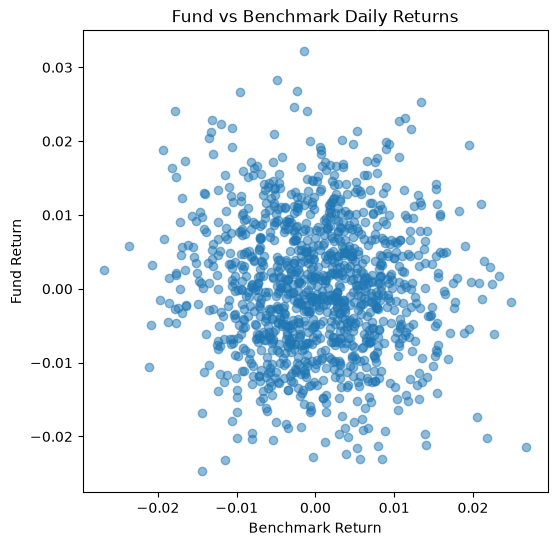

In [91]:
plt.figure(figsize=(6,6))

plt.scatter(
    sample_fund["benchmark_return"],
    sample_fund["daily_return"],
    alpha=0.5
)

plt.xlabel("Benchmark Return")
plt.ylabel("Fund Return")

plt.title("Fund vs Benchmark Daily Returns")

plt.show()

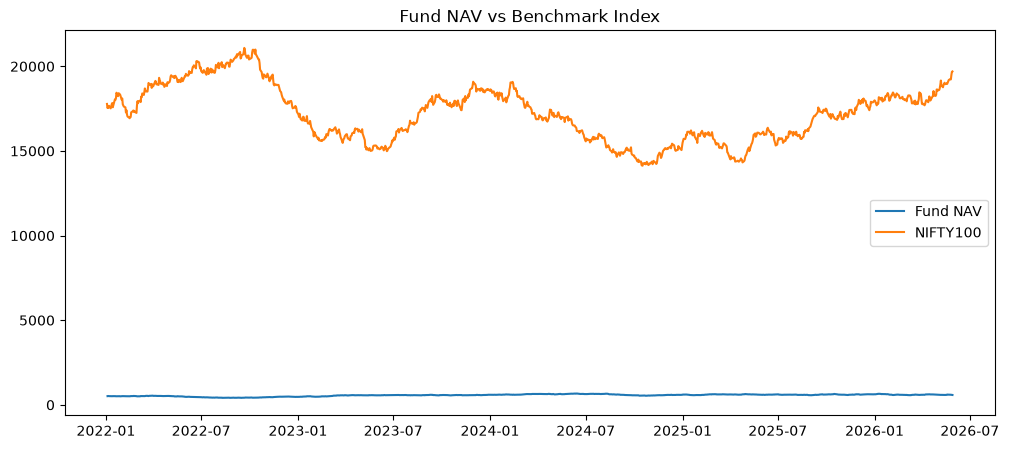

In [92]:
plt.figure(figsize=(12,5))

plt.plot(
    sample_fund["date"],
    sample_fund["nav"],
    label="Fund NAV"
)

plt.plot(
    benchmark_df["date"],
    benchmark_df["close_value"],
    label="NIFTY100"
)

plt.legend()

plt.title("Fund NAV vs Benchmark Index")

plt.show()

In [93]:
sample_fund["daily_return"].describe()

count    1149.000000
mean        0.000142
std         0.009164
min        -0.024744
25%        -0.006282
50%        -0.000070
75%         0.006523
max         0.032145
Name: daily_return, dtype: float64

In [94]:
benchmark_df["benchmark_return"].describe()

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

In [95]:
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [96]:
fund_master[
    [
        "scheme_name",
        "category",
        "sub_category",
        "benchmark",
    ]
].head(20)

,scheme_name,category,sub_category,benchmark
0,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,NIFTY 100 TRI
1,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,NIFTY 100 TRI
2,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,BSE 250 SmallCap TRI
3,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,BSE 250 SmallCap TRI
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,CRISIL Dynamic Gilt Index
5,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,NIFTY 100 TRI
6,HDFC Top 100 Fund - Direct Plan - Growth,Equity,Large Cap,NIFTY 100 TRI
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,NIFTY Midcap 150 TRI
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,Mid Cap,NIFTY Midcap 150 TRI
9,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration,CRISIL Short Term Bond Index


In [97]:
print(
    fund_master["benchmark"].value_counts()
)

benchmark
NIFTY 100 TRI                   14
BSE 250 SmallCap TRI             6
NIFTY Midcap 150 TRI             6
NIFTY 500 TRI                    4
CRISIL Liquid Fund AI Index      3
CRISIL Dynamic Gilt Index        2
NIFTY 50 TRI                     2
CRISIL Short Term Bond Index     1
NIFTY Midcap 50 TRI              1
NIFTY Large Midcap 250 TRI       1
Name: count, dtype: int64


Objective:
Compute Alpha and Beta for each fund using its designated benchmark specified in the fund master dataset.

In [99]:
benchmark_map = {
    "NIFTY 100 TRI": "NIFTY100",
    "NIFTY 50 TRI": "NIFTY50",
    "NIFTY Midcap 150 TRI": "NIFTY_MIDCAP150",
    "NIFTY 500 TRI": "NIFTY500",
    "BSE 250 SmallCap TRI": "BSE_SMALLCAP",
    "CRISIL Liquid Fund AI Index": "CRISIL_LIQUID",
    "CRISIL Dynamic Gilt Index": "CRISIL_GILT",
}

In [100]:
fund_master["mapped_benchmark"] = (
    fund_master["benchmark"]
    .map(benchmark_map)
)

fund_master[
    [
        "scheme_name",
        "benchmark",
        "mapped_benchmark",
    ]
].head(15)

,scheme_name,benchmark,mapped_benchmark
0,SBI Bluechip Fund - Regular Plan - Growth,NIFTY 100 TRI,NIFTY100
1,SBI Bluechip Fund - Direct Plan - Growth,NIFTY 100 TRI,NIFTY100
2,SBI Small Cap Fund - Regular Plan - Growth,BSE 250 SmallCap TRI,BSE_SMALLCAP
3,SBI Small Cap Fund - Direct Plan - Growth,BSE 250 SmallCap TRI,BSE_SMALLCAP
4,SBI Magnum Gilt Fund - Regular Plan - Growth,CRISIL Dynamic Gilt Index,CRISIL_GILT
5,HDFC Top 100 Fund - Regular Plan - Growth,NIFTY 100 TRI,NIFTY100
6,HDFC Top 100 Fund - Direct Plan - Growth,NIFTY 100 TRI,NIFTY100
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY Midcap 150 TRI,NIFTY_MIDCAP150
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,NIFTY Midcap 150 TRI,NIFTY_MIDCAP150
9,HDFC Short Term Debt Fund - Regular - Growth,CRISIL Short Term Bond Index,NaN


In [101]:
print("Mapped Benchmarks")

print(
    fund_master["mapped_benchmark"]
    .value_counts(dropna=False)
)

Mapped Benchmarks
mapped_benchmark
NIFTY100           14
BSE_SMALLCAP        6
NIFTY_MIDCAP150     6
NIFTY500            4
NaN                 3
CRISIL_LIQUID       3
CRISIL_GILT         2
NIFTY50             2
Name: count, dtype: int64


In [102]:
alpha_beta_returns_df = daily_returns_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "mapped_benchmark",
        ]
    ],
    on="amfi_code",
    how="left",
)

In [103]:
print(alpha_beta_returns_df.shape)

print(
    alpha_beta_returns_df[
        [
            "amfi_code",
            "scheme_name",
            "mapped_benchmark",
        ]
    ].head()
)

(64320, 6)
   amfi_code                                scheme_name mapped_benchmark
0     100016  HDFC Top 100 Fund - Regular Plan - Growth         NIFTY100
1     100016  HDFC Top 100 Fund - Regular Plan - Growth         NIFTY100
2     100016  HDFC Top 100 Fund - Regular Plan - Growth         NIFTY100
3     100016  HDFC Top 100 Fund - Regular Plan - Growth         NIFTY100
4     100016  HDFC Top 100 Fund - Regular Plan - Growth         NIFTY100


Compute Benchmark Returns

Calculate daily returns for each benchmark index available in the benchmark dataset.

In [104]:
benchmark_returns_df = benchmark_indices.copy()

benchmark_returns_df["date"] = pd.to_datetime(
    benchmark_returns_df["date"]
)

benchmark_returns_df = benchmark_returns_df.sort_values(
    [
        "index_name",
        "date",
    ]
)

benchmark_returns_df["benchmark_return"] = (
    benchmark_returns_df
    .groupby("index_name")["close_value"]
    .pct_change()
)

print("Shape:", benchmark_returns_df.shape)

benchmark_returns_df.head()

Shape: (8050, 4)


,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [105]:
print("Benchmarks:")
print(
    benchmark_returns_df["index_name"].unique()
)

print("\nMissing benchmark returns:")
print(
    benchmark_returns_df["benchmark_return"]
    .isna()
    .sum()
)

Benchmarks:
<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

Missing benchmark returns:
7


In [106]:
from scipy.stats import linregress

alpha_beta_results = []

for _, fund in fund_master.iterrows():

    benchmark_name = fund["mapped_benchmark"]

    if pd.isna(benchmark_name):
        continue

    fund_returns = alpha_beta_returns_df[
        alpha_beta_returns_df["amfi_code"] == fund["amfi_code"]
    ][
        [
            "date",
            "daily_return",
        ]
    ]

    benchmark_returns = benchmark_returns_df[
        benchmark_returns_df["index_name"] == benchmark_name
    ][
        [
            "date",
            "benchmark_return",
        ]
    ]

    merged = fund_returns.merge(
        benchmark_returns,
        on="date",
        how="inner",
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"],
    )

    alpha_beta_results.append(
        {
            "amfi_code": fund["amfi_code"],
            "scheme_name": fund["scheme_name"],
            "benchmark": benchmark_name,
            "alpha": intercept * TRADING_DAYS,
            "beta": slope,
            "r_squared": r_value ** 2,
            "p_value": p_value,
            "observations": len(merged),
        }
    )

alpha_beta_results_df = pd.DataFrame(alpha_beta_results)

print("Shape:", alpha_beta_results_df.shape)

alpha_beta_results_df.head()

Shape: (37, 8)


,amfi_code,scheme_name,benchmark,alpha,beta,r_squared,p_value,observations
0,119551,SBI Bluechip Fund - Regular Plan - Growth,NIFTY100,0.232010,-0.031751,8.869789e-04,0.313143,1149
1,119552,SBI Bluechip Fund - Direct Plan - Growth,NIFTY100,0.198686,-0.026159,5.850822e-04,0.412706,1149
2,119598,SBI Small Cap Fund - Regular Plan - Growth,BSE_SMALLCAP,0.315111,-0.047551,1.753760e-03,0.156013,1149
3,119599,SBI Small Cap Fund - Direct Plan - Growth,BSE_SMALLCAP,0.047784,0.011253,9.972526e-05,0.735255,1149
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,CRISIL_GILT,0.056107,-0.000935,9.468819e-07,0.973716,1149


In [107]:
print(alpha_beta_results_df.describe())

           amfi_code      alpha       beta     r_squared    p_value  \
count      37.000000  37.000000  37.000000  3.700000e+01  37.000000   
mean   120059.270270   0.158582  -0.001420  9.436632e-04   0.451046   
std     13969.947466   0.086093   0.033461  9.931272e-04   0.297139   
min    100016.000000   0.037476  -0.058268  2.247660e-09   0.034667   
25%    118633.000000   0.068995  -0.030177  1.305353e-04   0.205437   
50%    119552.000000   0.156438  -0.001884  5.850822e-04   0.412706   
75%    120842.000000   0.218294   0.023804  1.397445e-03   0.698852   
max    149324.000000   0.315111   0.059502  3.883861e-03   0.998719   

       observations  
count          37.0  
mean         1149.0  
std             0.0  
min          1149.0  
25%          1149.0  
50%          1149.0  
75%          1149.0  
max          1149.0  


In [108]:
print("\nHighest Beta")

print(
    alpha_beta_results_df.nlargest(
        5,
        "beta",
    )[
        [
            "scheme_name",
            "benchmark",
            "beta",
            "alpha",
            "r_squared",
        ]
    ]
)


Highest Beta
                                          scheme_name        benchmark  \
13           ICICI Pru Liquid Fund - Regular - Growth    CRISIL_LIQUID   
8   HDFC Mid-Cap Opportunities Fund - Direct - Growth  NIFTY_MIDCAP150   
12  ICICI Pru Value Discovery Fund - Regular - Growth         NIFTY500   
6            HDFC Top 100 Fund - Direct Plan - Growth         NIFTY100   
33      Mirae Asset Tax Saver Fund - Regular - Growth         NIFTY500   

        beta     alpha  r_squared  
13  0.059502  0.063676   0.003884  
8   0.059234  0.103438   0.003310  
12  0.054835  0.152088   0.002492  
6   0.048820  0.177298   0.001840  
33  0.038195  0.275084   0.000898  


In [109]:
print("\nHighest R²")

print(
    alpha_beta_results_df.nlargest(
        5,
        "r_squared",
    )[
        [
            "scheme_name",
            "benchmark",
            "beta",
            "r_squared",
        ]
    ]
)


Highest R²
                                          scheme_name        benchmark  \
13           ICICI Pru Liquid Fund - Regular - Growth    CRISIL_LIQUID   
8   HDFC Mid-Cap Opportunities Fund - Direct - Growth  NIFTY_MIDCAP150   
5           HDFC Top 100 Fund - Regular Plan - Growth         NIFTY100   
12  ICICI Pru Value Discovery Fund - Regular - Growth         NIFTY500   
30                UTI Mid Cap Fund - Regular - Growth  NIFTY_MIDCAP150   

        beta  r_squared  
13  0.059502   0.003884  
8   0.059234   0.003310  
5  -0.058268   0.002665  
12  0.054835   0.002492  
30 -0.049090   0.002328  


In [110]:
print(
    "Funds skipped due to unavailable benchmark:",
    fund_master["mapped_benchmark"].isna().sum()
)

Funds skipped due to unavailable benchmark: 3


In [111]:
alpha_beta_results_df.to_csv(
    "../data/analytics/alpha_beta.csv",
    index=False
)

print("Saved: ../data/analytics/alpha_beta.csv")

Saved: ../data/analytics/alpha_beta.csv


### Task 6 - Maximum Drawdown

Objective:
Measure the largest peak-to-trough decline experienced by each mutual fund over the available historical period.

In [112]:
drawdown_df = nav_history.copy()

drawdown_df["date"] = pd.to_datetime(drawdown_df["date"])

drawdown_df = drawdown_df.sort_values(
    [
        "amfi_code",
        "date",
    ]
)

print(drawdown_df.shape)

drawdown_df.head()

(64320, 3)


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [113]:
drawdown_df["running_max"] = (
    drawdown_df
    .groupby("amfi_code")["nav"]
    .cummax()
)

In [114]:
drawdown_df["drawdown"] = (
    drawdown_df["nav"]
    /
    drawdown_df["running_max"]
) - 1

In [115]:
drawdown_df.head(10)

,date,amfi_code,nav,running_max,drawdown
0,2022-01-03,100016,520.4608,520.4608,0.000000
1,2022-01-04,100016,515.0971,520.4608,-0.010306
2,2022-01-05,100016,521.7239,521.7239,0.000000
3,2022-01-06,100016,515.7880,521.7239,-0.011377
4,2022-01-07,100016,515.1639,521.7239,-0.012574
5,2022-01-08,100016,515.1639,521.7239,-0.012574
6,2022-01-09,100016,515.1639,521.7239,-0.012574
7,2022-01-10,100016,510.7136,521.7239,-0.021104
8,2022-01-11,100016,513.5542,521.7239,-0.015659
9,2022-01-12,100016,512.3195,521.7239,-0.018026


In [116]:
max_drawdown_df = (
    drawdown_df
    .groupby("amfi_code")
    .agg(
        max_drawdown=(
            "drawdown",
            "min",
        )
    )
    .reset_index()
)

In [117]:
max_drawdown_df = max_drawdown_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
        ]
    ],
    on="amfi_code",
    how="left",
)

In [118]:
max_drawdown_df = max_drawdown_df[
    [
        "amfi_code",
        "scheme_name",
        "max_drawdown",
    ]
]

In [119]:
print(max_drawdown_df.shape)

print(max_drawdown_df.head())

print(max_drawdown_df.describe())

(40, 3)
   amfi_code                                        scheme_name  max_drawdown
0     100016          HDFC Top 100 Fund - Regular Plan - Growth     -0.247344
1     100025       HDFC Short Term Debt Fund - Regular - Growth     -0.043083
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     -0.162172
3     101206      ABSL Frontline Equity Fund - Regular - Growth     -0.112916
4     101207             ABSL Small Cap Fund - Regular - Growth     -0.354469
           amfi_code  max_drawdown
count      40.000000     40.000000
mean   120247.000000     -0.178729
std     14534.998667      0.112686
min    100016.000000     -0.525742
25%    118632.750000     -0.215927
50%    119551.500000     -0.163070
75%    120842.250000     -0.117653
max    149324.000000     -0.000977


In [120]:
drawdown_results = []

for amfi_code, fund_data in drawdown_df.groupby("amfi_code"):

    trough_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    trough_date = trough_row["date"]
    max_drawdown = trough_row["drawdown"]

    peak_nav = trough_row["running_max"]

    peak_date = fund_data[
        (fund_data["nav"] == peak_nav) &
        (fund_data["date"] <= trough_date)
    ]["date"].iloc[0]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "max_drawdown": max_drawdown,
    })

drawdown_results_df = pd.DataFrame(drawdown_results)

In [121]:
drawdown_results_df = drawdown_results_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
        ]
    ],
    on="amfi_code",
    how="left",
)

In [122]:
drawdown_results_df = drawdown_results_df[
    [
        "amfi_code",
        "scheme_name",
        "peak_date",
        "trough_date",
        "max_drawdown",
    ]
]

In [123]:
print(drawdown_results_df.shape)

drawdown_results_df.head()

(40, 5)


,amfi_code,scheme_name,peak_date,trough_date,max_drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-03-30,2022-09-15,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,2023-05-23,2023-07-28,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-03-11,2022-05-12,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,2023-04-24,2023-07-05,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,2024-11-21,2026-05-11,-0.354469


In [163]:
drawdown_results_df.to_csv(
    "../data/analytics/max_drawdown.csv",
    index=False,
)

print("Saved max_drawdown.csv")

Saved max_drawdown.csv


### Task 7 - Fund Scorecard
Develop a composite fund score (0–100) by combining key performance and risk metrics using weighted ranking. The score incorporates 3-year CAGR, Sharpe Ratio, Alpha, Expense Ratio, and Maximum Drawdown to provide an overall assessment of each mutual fund.

In [133]:
print(cagr_results_df.shape)

print(cagr_results_df.columns)

print(cagr_results_df.isna().sum())

cagr_results_df.head()

(40, 5)
Index(['amfi_code', 'scheme_name', 'cagr_1y', 'cagr_3y', 'cagr_5y'], dtype='str')
amfi_code       0
scheme_name     0
cagr_1y         0
cagr_3y         0
cagr_5y        40
dtype: int64


,amfi_code,scheme_name,cagr_1y,cagr_3y,cagr_5y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,NaN


In [140]:
print(fund_statistics_df.columns)

fund_statistics_df.head()

Index(['amfi_code', 'scheme_name', 'mean_daily_return', 'daily_volatility',
       'sharpe_ratio', 'sharpe_rank'],
      dtype='str')


,amfi_code,scheme_name,mean_daily_return,daily_volatility,sharpe_ratio,sharpe_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.000768,0.007575,1.068224,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,0.000773,0.008475,0.965561,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.000804,0.009427,0.919047,3.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.000830,0.010288,0.883256,4.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000656,0.007330,0.860977,5.0


In [135]:
print(alpha_beta_results_df.shape)

print(alpha_beta_results_df.columns)

print(alpha_beta_results_df.isna().sum())

alpha_beta_results_df.head()

(37, 8)
Index(['amfi_code', 'scheme_name', 'benchmark', 'alpha', 'beta', 'r_squared',
       'p_value', 'observations'],
      dtype='str')
amfi_code       0
scheme_name     0
benchmark       0
alpha           0
beta            0
r_squared       0
p_value         0
observations    0
dtype: int64


,amfi_code,scheme_name,benchmark,alpha,beta,r_squared,p_value,observations
0,119551,SBI Bluechip Fund - Regular Plan - Growth,NIFTY100,0.232010,-0.031751,8.869789e-04,0.313143,1149
1,119552,SBI Bluechip Fund - Direct Plan - Growth,NIFTY100,0.198686,-0.026159,5.850822e-04,0.412706,1149
2,119598,SBI Small Cap Fund - Regular Plan - Growth,BSE_SMALLCAP,0.315111,-0.047551,1.753760e-03,0.156013,1149
3,119599,SBI Small Cap Fund - Direct Plan - Growth,BSE_SMALLCAP,0.047784,0.011253,9.972526e-05,0.735255,1149
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,CRISIL_GILT,0.056107,-0.000935,9.468819e-07,0.973716,1149


In [136]:
print(fund_master.shape)

print(
    fund_master[
        [
            "amfi_code",
            "expense_ratio_pct",
        ]
    ].isna().sum()
)

fund_master[
    [
        "amfi_code",
        "expense_ratio_pct",
    ]
].head()

(40, 16)
amfi_code            0
expense_ratio_pct    0
dtype: int64


,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [138]:
print(drawdown_results_df.shape)

print(drawdown_results_df.columns)

print(drawdown_results_df.isna().sum())

drawdown_results_df.head()

(40, 5)
Index(['amfi_code', 'scheme_name', 'peak_date', 'trough_date', 'max_drawdown'], dtype='str')
amfi_code       0
scheme_name     0
peak_date       0
trough_date     0
max_drawdown    0
dtype: int64


,amfi_code,scheme_name,peak_date,trough_date,max_drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-03-30,2022-09-15,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,2023-05-23,2023-07-28,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-03-11,2022-05-12,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,2023-04-24,2023-07-05,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,2024-11-21,2026-05-11,-0.354469


In [139]:
missing_alpha = set(fund_master["amfi_code"]) - set(alpha_beta_results_df["amfi_code"])

print("Funds without Alpha:", len(missing_alpha))

print(sorted(missing_alpha))

Funds without Alpha: 3
[100025, 119094, 148568]


In [141]:
scorecard_df = cagr_results_df[
    [
        "amfi_code",
        "scheme_name",
        "cagr_3y",
    ]
]

scorecard_df = scorecard_df.merge(
    fund_statistics_df[
        [
            "amfi_code",
            "sharpe_ratio",
        ]
    ],
    on="amfi_code",
    how="inner",
)

scorecard_df = scorecard_df.merge(
    alpha_beta_results_df[
        [
            "amfi_code",
            "alpha",
        ]
    ],
    on="amfi_code",
    how="inner",
)

scorecard_df = scorecard_df.merge(
    fund_master[
        [
            "amfi_code",
            "expense_ratio_pct",
        ]
    ],
    on="amfi_code",
    how="inner",
)

scorecard_df = scorecard_df.merge(
    drawdown_results_df[
        [
            "amfi_code",
            "max_drawdown",
        ]
    ],
    on="amfi_code",
    how="inner",
)

print(scorecard_df.shape)

scorecard_df.head()

(37, 7)


,amfi_code,scheme_name,cagr_3y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.012926,-0.321019,0.037476,1.55,-0.247344
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324425,0.808268,0.263347,1.38,-0.162172
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.289677,0.717409,0.213998,1.60,-0.112916
3,101207,ABSL Small Cap Fund - Regular - Growth,-0.041524,0.052618,0.119693,1.53,-0.354469
4,101208,ABSL Liquid Fund - Regular - Growth,0.063158,-4.650401,0.062783,0.79,-0.001622


In [142]:
scorecard_df["cagr_rank"] = (
    scorecard_df["cagr_3y"]
    .rank(ascending=False, method="dense")
)

scorecard_df["sharpe_rank"] = (
    scorecard_df["sharpe_ratio"]
    .rank(ascending=False, method="dense")
)

scorecard_df["alpha_rank"] = (
    scorecard_df["alpha"]
    .rank(ascending=False, method="dense")
)

scorecard_df["expense_rank"] = (
    scorecard_df["expense_ratio_pct"]
    .rank(ascending=True, method="dense")
)

scorecard_df["drawdown_rank"] = (
    scorecard_df["max_drawdown"]
    .rank(ascending=False, method="dense")
)

In [143]:
max_rank = scorecard_df["cagr_rank"].max()

scorecard_df["cagr_score"] = (
    (max_rank - scorecard_df["cagr_rank"])
    /
    (max_rank - 1)
) * 100

scorecard_df["sharpe_score"] = (
    (max_rank - scorecard_df["sharpe_rank"])
    /
    (max_rank - 1)
) * 100

scorecard_df["alpha_score"] = (
    (max_rank - scorecard_df["alpha_rank"])
    /
    (max_rank - 1)
) * 100

scorecard_df["expense_score"] = (
    (max_rank - scorecard_df["expense_rank"])
    /
    (max_rank - 1)
) * 100

scorecard_df["drawdown_score"] = (
    (max_rank - scorecard_df["drawdown_rank"])
    /
    (max_rank - 1)
) * 100

In [144]:
scorecard_df["fund_score"] = (
      0.30 * scorecard_df["cagr_score"]
    + 0.25 * scorecard_df["sharpe_score"]
    + 0.20 * scorecard_df["alpha_score"]
    + 0.15 * scorecard_df["expense_score"]
    + 0.10 * scorecard_df["drawdown_score"]
)

In [145]:
scorecard_df = scorecard_df.sort_values(
    "fund_score",
    ascending=False,
).reset_index(drop=True)

scorecard_df["overall_rank"] = (
    scorecard_df.index + 1
)

In [147]:
print(scorecard_df.shape)

scorecard_df[
    [
        "overall_rank",
        "scheme_name",
        "fund_score",
    ]
].head(10)

(37, 19)


,overall_rank,scheme_name,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,88.055556
1,2,Kotak Flexicap Fund - Regular - Growth,83.333333
2,3,ICICI Pru Midcap Fund - Regular - Growth,83.194444
3,4,ICICI Pru Bluechip Fund - Direct - Growth,80.277778
4,5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.138889
5,6,SBI Bluechip Fund - Regular Plan - Growth,76.111111
6,7,Mirae Asset Tax Saver Fund - Regular - Growth,75.138889
7,8,ABSL Frontline Equity Fund - Regular - Growth,69.861111
8,9,DSP Midcap Fund - Regular - Growth,68.750000
9,10,SBI Small Cap Fund - Regular Plan - Growth,68.472222


In [148]:
scorecard_df["fund_score"].describe()

count    37.000000
mean     51.092342
std      21.485252
min      14.722222
25%      32.638889
50%      50.833333
75%      68.472222
max      88.055556
Name: fund_score, dtype: float64

In [149]:
fund_scorecard_df = scorecard_df[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "fund_score",
        "cagr_3y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
    ]
]

fund_scorecard_df.head()

,overall_rank,amfi_code,scheme_name,fund_score,cagr_3y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,88.055556,0.340009,1.068224,0.269838,1.46,-0.112657
1,2,120843,Kotak Flexicap Fund - Regular - Growth,83.333333,0.295828,0.965561,0.277943,1.45,-0.129740
2,3,120505,ICICI Pru Midcap Fund - Regular - Growth,83.194444,0.317775,0.883256,0.293099,1.36,-0.181885
3,4,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.277778,0.324874,0.714682,0.211948,0.80,-0.125883
4,5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.138889,0.324425,0.808268,0.263347,1.38,-0.162172


In [150]:
fund_scorecard_df.to_csv(
    "../data/analytics/fund_scorecard.csv",
    index=False,
)

print("Saved fund_scorecard.csv")

Saved fund_scorecard.csv


### Benchmark comparison chart 
 plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error = std(fund_return − benchmark_return) × √252.

In [151]:
top5_funds = fund_scorecard_df.nsmallest(
    5,
    "overall_rank"
)

top5_funds

,overall_rank,amfi_code,scheme_name,fund_score,cagr_3y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,88.055556,0.340009,1.068224,0.269838,1.46,-0.112657
1,2,120843,Kotak Flexicap Fund - Regular - Growth,83.333333,0.295828,0.965561,0.277943,1.45,-0.129740
2,3,120505,ICICI Pru Midcap Fund - Regular - Growth,83.194444,0.317775,0.883256,0.293099,1.36,-0.181885
3,4,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.277778,0.324874,0.714682,0.211948,0.80,-0.125883
4,5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.138889,0.324425,0.808268,0.263347,1.38,-0.162172


In [153]:
top5_nav = nav_history.copy()

top5_nav["date"] = pd.to_datetime(top5_nav["date"])

latest_date = top5_nav["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

print(start_date.date())
print(latest_date.date())

2023-05-29
2026-05-29


In [154]:
top5_nav = top5_nav[
    top5_nav["amfi_code"].isin(
        top5_funds["amfi_code"]
    )
]

top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

print(top5_nav.shape)

top5_nav.head()

(5485, 3)


,date,amfi_code,nav
3727,2023-05-29,100033,147.2155
3728,2023-05-30,100033,147.2007
3729,2023-05-31,100033,147.4640
3730,2023-06-01,100033,146.5954
3731,2023-06-02,100033,145.8015


In [155]:
top5_nav = top5_nav.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
        ]
    ],
    on="amfi_code",
    how="left",
)

In [156]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(
        lambda x: (x / x.iloc[0]) * 100
    )
)

In [157]:
top5_nav.head()

,date,amfi_code,nav,scheme_name,normalized_nav
0,2023-05-29,100033,147.2155,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.000000
1,2023-05-30,100033,147.2007,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.989947
2,2023-05-31,100033,147.4640,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.168800
3,2023-06-01,100033,146.5954,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.578781
4,2023-06-02,100033,145.8015,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.039503


In [158]:
benchmark_plot = benchmark_indices.copy()

benchmark_plot["date"] = pd.to_datetime(
    benchmark_plot["date"]
)

benchmark_plot = benchmark_plot[
    benchmark_plot["index_name"].isin(
        [
            "NIFTY50",
            "NIFTY100",
        ]
    )
]

benchmark_plot = benchmark_plot[
    benchmark_plot["date"] >= start_date
]

In [159]:
benchmark_plot["normalized_index"] = (
    benchmark_plot.groupby("index_name")["close_value"]
    .transform(
        lambda x: (x / x.iloc[0]) * 100
    )
)

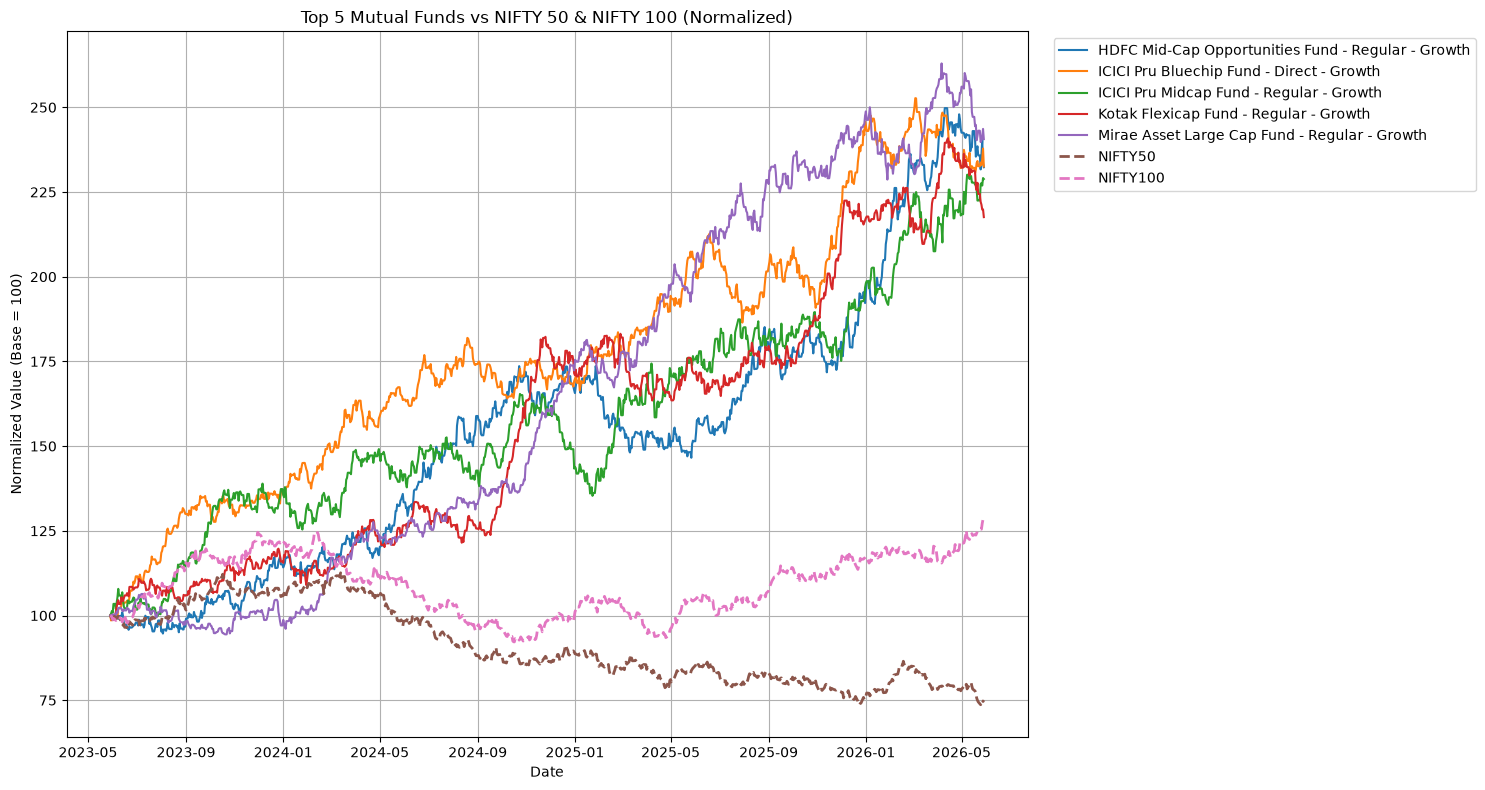

In [160]:
plt.figure(figsize=(15, 8))

for scheme in top5_nav["scheme_name"].unique():

    data = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    plt.plot(
        data["date"],
        data["normalized_nav"],
        label=scheme,
    )

for benchmark in benchmark_plot["index_name"].unique():

    data = benchmark_plot[
        benchmark_plot["index_name"] == benchmark
    ]

    plt.plot(
        data["date"],
        data["normalized_index"],
        linestyle="--",
        linewidth=2,
        label=benchmark,
    )

plt.title("Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100 (Normalized)")

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [161]:
tracking_error_results = []

for _, fund in top5_funds.iterrows():

    benchmark = fund_master.loc[
        fund_master["amfi_code"] == fund["amfi_code"],
        "mapped_benchmark"
    ].iloc[0]

    if pd.isna(benchmark):
        continue

    fund_returns = daily_returns_df[
        daily_returns_df["amfi_code"] == fund["amfi_code"]
    ][["date", "daily_return"]]

    benchmark_returns = benchmark_returns_df[
        benchmark_returns_df["index_name"] == benchmark
    ][["date", "benchmark_return"]]

    merged = fund_returns.merge(
        benchmark_returns,
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(TRADING_DAYS)
    )

    tracking_error_results.append({
        "scheme_name": fund["scheme_name"],
        "benchmark": benchmark,
        "tracking_error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df

,scheme_name,benchmark,tracking_error
0,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,0.189664
1,Kotak Flexicap Fund - Regular - Growth,NIFTY500,0.213127
2,ICICI Pru Midcap Fund - Regular - Growth,NIFTY_MIDCAP150,0.262847
3,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,0.191587
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY_MIDCAP150,0.256247


In [162]:
tracking_error_df.to_csv(
    "../data/analytics/tracking_error.csv",
    index=False
)

print("Tracking Error exported successfully.")

Tracking Error exported successfully.


# Conclusion

This notebook analyzed the performance and risk characteristics of 40 mutual fund schemes using historical NAV data. Key performance metrics including Daily Returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, and a composite Fund Scorecard were computed. The analysis also included benchmark comparison and tracking error evaluation for the top-performing funds. The resulting datasets and visualizations can be directly used for interactive reporting and dashboard development in Power BI.